<a href="https://colab.research.google.com/github/LongLongoooo/AIO_233/blob/AIO_Module_5/M05W04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Gradient Descent**

In [ ]:
import numpy as np

def df_W(W):
    """
    Calculate the gradient of the function f(w1, w2) = 0.1w1^2 + 2w2^2.
    """
    # Coefficient matrix for the diagonal terms in the gradient
    coefficient = np.diag([0.2, 4])
    # Gradient calculation
    dw = np.dot(W, coefficient)
    return dw

def sgd(W, dW, lr):
    """
    Update weights using Stochastic Gradient Descent (SGD).
    """
    W = W - lr * dW
    return W

def train_pl(optimizer, lr, epochs):
    """
    Train the model over a given number of epochs,
    using the provided optimizer and learning rate.
    """
    # Initial weights
    W = np.array([-5, -2], dtype=np.float32)
    results = [W]  # List to store W over all epochs

    for epoch in range(epochs):
        # Compute the gradient
        dW = df_W(W)
        # Update weights using the optimizer
        W = optimizer(W, dW, lr)
        # Store the updated weights
        results.append(W)

    return results

# Training process
weights_history = train_pl(sgd, lr=0.01, epochs=30)

# Print the results
for epoch, W in enumerate(weights_history):
    print(f"Epoch {epoch}: W = {W}")


Epoch 0: W = [-5. -2.]
Epoch 1: W = [-4.99 -1.92]
Epoch 2: W = [-4.98002 -1.8432 ]
Epoch 3: W = [-4.97005996 -1.769472  ]
Epoch 4: W = [-4.96011984 -1.69869312]
Epoch 5: W = [-4.9501996 -1.6307454]
Epoch 6: W = [-4.9402992  -1.56551558]
Epoch 7: W = [-4.9304186  -1.50289496]
Epoch 8: W = [-4.92055777 -1.44277916]
Epoch 9: W = [-4.91071665 -1.38506799]
Epoch 10: W = [-4.90089522 -1.32966527]
Epoch 11: W = [-4.89109343 -1.27647866]
Epoch 12: W = [-4.88131124 -1.22541951]
Epoch 13: W = [-4.87154862 -1.17640273]
Epoch 14: W = [-4.86180552 -1.12934662]
Epoch 15: W = [-4.85208191 -1.08417276]
Epoch 16: W = [-4.84237774 -1.04080585]
Epoch 17: W = [-4.83269299 -0.99917362]
Epoch 18: W = [-4.8230276  -0.95920667]
Epoch 19: W = [-4.81338155 -0.9208384 ]
Epoch 20: W = [-4.80375479 -0.88400487]
Epoch 21: W = [-4.79414728 -0.84864467]
Epoch 22: W = [-4.78455898 -0.81469889]
Epoch 23: W = [-4.77498986 -0.78211093]
Epoch 24: W = [-4.76543988 -0.75082649]
Epoch 25: W = [-4.755909   -0.72079343]
Epoch 

# **Gradient Descent + Momentum**

In [24]:
import numpy as np

def df_W(W):
    """
    Compute the gradient of the function f with respect to W.
    """
    return np.dot(W, np.diag([0.2, 4]))

def velocity(dW, V, momentum):
    """
    Update the velocity using the momentum term.
    """
    return momentum * V + (1 - momentum) * dW

def sgd_momentum(W, lr, Vel):
    """
    Update weights using momentum-based gradient descent.
    """
    return W - lr * Vel

def train_pl(lr, momentum, epochs):
    """
    Train a model using momentum-based stochastic gradient descent.

    Parameters:
        lr (float): Learning rate.
        momentum (float): Momentum coefficient.
        epochs (int): Number of epochs to train.

    Returns:
        list: A list of weights at each epoch.
    """
    # Initialize weights and velocity
    W = np.array([-5, -2], dtype=float)
    V = np.zeros_like(W)
    results = [W.copy()]

    for epoch in range(epochs):
        # Compute the gradient
        dW = df_W(W)

        # Update the velocity
        V = velocity(dW, V, momentum)

        # Update weights
        W = sgd_momentum(W=W, lr=lr, Vel=V)
        results.append(W.copy())

        # Print progress
        print(f"Epoch {epoch + 1}:")
        print(f"  Gradient (dW): {np.round(dW, 5)}")
        print(f"  Velocity (V): {np.round(V, 5)}")
        print(f"  Updated Weights (W): {np.round(W, 5)}\n")

    return results

# Run the training loop
train_pl(lr=0.1, momentum=0.9, epochs=30)


Epoch 1:
  Gradient (dW): [-1. -8.]
  Velocity (V): [-0.1 -0.8]
  Updated Weights (W): [-4.99 -1.92]

Epoch 2:
  Gradient (dW): [-0.998 -7.68 ]
  Velocity (V): [-0.1898 -1.488 ]
  Updated Weights (W): [-4.97102 -1.7712 ]

Epoch 3:
  Gradient (dW): [-0.9942 -7.0848]
  Velocity (V): [-0.27024 -2.04768]
  Updated Weights (W): [-4.944   -1.56643]

Epoch 4:
  Gradient (dW): [-0.9888  -6.26573]
  Velocity (V): [-0.3421  -2.46948]
  Updated Weights (W): [-4.90979 -1.31948]

Epoch 5:
  Gradient (dW): [-0.98196 -5.27793]
  Velocity (V): [-0.40608 -2.75033]
  Updated Weights (W): [-4.86918 -1.04445]

Epoch 6:
  Gradient (dW): [-0.97384 -4.1778 ]
  Velocity (V): [-0.46286 -2.89308]
  Updated Weights (W): [-4.82289 -0.75514]

Epoch 7:
  Gradient (dW): [-0.96458 -3.02057]
  Velocity (V): [-0.51303 -2.90583]
  Updated Weights (W): [-4.77159 -0.46456]

Epoch 8:
  Gradient (dW): [-0.95432 -1.85824]
  Velocity (V): [-0.55716 -2.80107]
  Updated Weights (W): [-4.71587 -0.18445]

Epoch 9:
  Gradient (dW)

[array([-5., -2.]),
 array([-4.99, -1.92]),
 array([-4.97102, -1.7712 ]),
 array([-4.94399596, -1.566432  ]),
 array([-4.90978633, -1.31948352]),
 array([-4.86917809, -1.04445055]),
 array([-4.82289232, -0.75514285]),
 array([-4.77158935, -0.46456021]),
 array([-4.71587349, -0.18445342]),
 array([-4.65629747,  0.07502082]),
 array([-4.59336645,  0.30554681]),
 array([-4.52754181,  0.50079832]),
 array([-4.45924455,  0.65649276]),
 array([-4.38885852,  0.77035803]),
 array([-4.31673338,  0.84202246]),
 array([-4.24318729,  0.87283955]),
 array([-4.16850943,  0.86566135]),
 array([-4.09296234,  0.82457451]),
 array([-4.01678403,  0.75461338]),
 array([-3.94018998,  0.66146382]),
 array([-3.86337496,  0.55117067]),
 array([-3.7865147,  0.42986  ]),
 array([-3.70976743,  0.30348601]),
 array([-3.63327535,  0.17760997]),
 array([-3.55716593,  0.05721713]),
 array([-3.48155312, -0.0534251 ]),
 array([-3.40653848, -0.15086611]),
 array([-3.33221223, -0.23252837]),
 array([-3.25865418, -0.2967

# **RMSPRop**

In [10]:
import numpy as np

def compute_gradient(W):
    """
    Compute the gradient of the objective function with respect to W.
    Here, we assume a simple linear function with a diagonal matrix for simplicity.
    """
    return np.dot(W, np.diag([0.2, 4]))

def update_ema(S, decay_rate, gradient_squared):
    """
    Update the Exponential Moving Average (EMA) of squared gradients.

    Parameters:
        S (ndarray): The previous EMA of squared gradients.
        decay_rate (float): The decay factor for EMA.
        gradient_squared (ndarray): The square of the gradients.

    Returns:
        ndarray: The updated EMA of squared gradients.
    """
    return decay_rate * S + (1 - decay_rate) * gradient_squared

def rmsprop_update(W, lr, gradient, ema, epsilon=0.001):
    """
    Perform a single update using the RMSProp optimizer.

    Parameters:
        W (ndarray): The current weights.
        lr (float): The learning rate.
        gradient (ndarray): The gradient of the objective function.
        ema (ndarray): The Exponential Moving Average of squared gradients.
        epsilon (float): A small constant to prevent division by zero.

    Returns:
        ndarray: The updated weights.
    """
    return W - lr * (gradient / np.sqrt(ema + epsilon))

def train_rmsprop(lr, decay_rate, epochs):
    """
    Train a simple model using the RMSProp optimization algorithm.

    Parameters:
        lr (float): The learning rate for RMSProp.
        decay_rate (float): The decay rate for EMA.
        epochs (int): The number of training iterations (epochs).
    """
    # Initialize weights (W) and EMA (S) for RMSProp
    W = np.array([-5, -2])
    S = np.zeros_like(W)  # EMA initialized to zero
    results = [W.copy()]

    # Training loop
    for epoch in range(epochs):
        # Compute gradient
        gradient = compute_gradient(W)

        # Update EMA with squared gradients
        S = update_ema(S, decay_rate, gradient**2)

        # Update weights using RMSProp
        W = rmsprop_update(W, lr, gradient, S)

        # Save the updated weights for tracking
        results.append(W.copy())

        # Print progress (optional for monitoring training)
        print(f"Epoch {epoch + 1}:")
        print(f"  Gradient (dW): {np.round(gradient, 5)}")
        print(f"  EMA (S): {np.round(S, 5)}")
        print(f"  Updated Weights (W): {np.round(W, 5)}\n")

    return results

# Call the training function with parameters
train_rmsprop(lr=0.1, decay_rate=0.9, epochs=30)


Epoch 1:
  Gradient (dW): [-1. -8.]
  EMA (S): [0.1 6.4]
  Updated Weights (W): [-4.68534 -1.6838 ]

Epoch 2:
  Gradient (dW): [-0.93707 -6.73519]
  EMA (S): [ 0.17781 10.29628]
  Updated Weights (W): [-4.46374 -1.47391]

Epoch 3:
  Gradient (dW): [-0.89275 -5.89563]
  EMA (S): [ 0.23973 12.7425 ]
  Updated Weights (W): [-4.28178 -1.30876]

Epoch 4:
  Gradient (dW): [-0.85636 -5.23502]
  EMA (S): [ 0.28909 14.20879]
  Updated Weights (W): [-4.12279 -1.16988]

Epoch 5:
  Gradient (dW): [-0.82456 -4.67952]
  EMA (S): [ 0.32817 14.97771]
  Updated Weights (W): [-3.97907 -1.04897]

Epoch 6:
  Gradient (dW): [-0.79581 -4.19588]
  EMA (S): [ 0.35869 15.24048]
  Updated Weights (W): [-3.84638 -0.94149]

Epoch 7:
  Gradient (dW): [-0.76928 -3.76598]
  EMA (S): [ 0.382   15.13469]
  Updated Weights (W): [-3.72207 -0.84469]

Epoch 8:
  Gradient (dW): [-0.74441 -3.37878]
  EMA (S): [ 0.39921 14.76283]
  Updated Weights (W): [-3.6044  -0.75676]

Epoch 9:
  Gradient (dW): [-0.72088 -3.02704]
  EMA 

[array([-5, -2]),
 array([-4.68534161, -1.68379694]),
 array([-4.46373857, -1.47390849]),
 array([-4.28178318, -1.30875559]),
 array([-4.12278653, -1.16988041]),
 array([-3.97906886, -1.04896983]),
 array([-3.84637529, -0.94149433]),
 array([-3.72207138, -0.84469405]),
 array([-3.60440022, -0.75675943]),
 array([-3.49212626, -0.67644106]),
 array([-3.38434549, -0.6028422 ]),
 array([-3.28037592, -0.53529892]),
 array([-3.1796906 , -0.47330602]),
 array([-3.08187449, -0.4164687 ]),
 array([-2.98659564, -0.36446932]),
 array([-2.89358531, -0.31704367]),
 array([-2.80262382, -0.27396327]),
 array([-2.71353028, -0.23502194]),
 array([-2.62615494, -0.20002528]),
 array([-2.54037344, -0.16878259]),
 array([-2.45608239, -0.14110069]),
 array([-2.37319593, -0.11677955]),
 array([-2.29164302, -0.09560958]),
 array([-2.21136531, -0.0773704 ]),
 array([-2.13231539, -0.06183126]),
 array([-2.0544554 , -0.04875267]),
 array([-1.97775592, -0.03788924]),
 array([-1.90219501, -0.02899346]),
 array([-1

# **Adam**

In [20]:
import numpy as np

def df_W(W):
    """Compute the gradient of W."""
    return np.dot(W, np.diag([0.2, 4]))

def velocity(V, momentum, dW):
    """Update the velocity with momentum."""
    V = momentum * V + (1 - momentum) * dW
    return V

def EMA(S, decay_rate, dW):
    """Compute the Exponential Moving Average (EMA) of the gradient squares."""
    S = decay_rate * S + (1 - decay_rate) * (dW ** 2)
    return S

def V_corr(V, momentum, epoch):
    """Apply bias correction to the velocity."""
    V_corr = V / (1 - momentum ** epoch)
    return V_corr

def S_corr(S, decay_rate, epoch):
    """Apply bias correction to the EMA."""
    S_corr = S / (1 - decay_rate ** epoch)
    return S_corr

def Adam(W, lr, V_corr, S_corr, epsilon=0.001):
    """Update weights using the Adam optimizer."""
    W = W - lr * (V_corr / (np.sqrt(S_corr) + epsilon))
    return W

def train_pl(lr, momentum, decay_rate, epochs):
    """Train the model with Adam optimizer."""
    # Initial weights, EMA, and velocity
    W = np.array([-5, -2])
    S = np.zeros_like(W)
    V = np.zeros_like(W)
    result = [W]

    # Training loop
    for epoch in range(1, epochs + 1):
        # Compute gradient
        dW = df_W(W)

        # Update velocity (momentum)
        V = velocity(V, momentum, dW)

        # Update EMA of squared gradients
        S = EMA(S, decay_rate, dW)

        # Apply bias correction
        v_corr = V_corr(V, momentum, epoch)
        s_corr = S_corr(S, decay_rate, epoch)

        # Update weights using Adam optimizer
        W = Adam(W, lr, v_corr, s_corr)

        # Store the updated weights
        result.append(W.copy())

        # Print progress for monitoring
        print(f"Epoch {epoch}:")
        print(f"  Gradient (dW): {np.round(dW, 5)}")
        print(f"  Velocity (V): {np.round(V, 5)}")
        print(f"  EMA (S): {np.round(S, 5)}")
        print(f"  Velocity_corr (V_corr): {np.round(v_corr, 5)}")
        print(f"  EMA_corr (S_corr): {np.round(s_corr, 5)}")
        print(f"  Updated Weights (W): {np.round(W, 5)}\n")

    return result

# Run the training for 2 epochs with the specified parameters
train_pl(lr=0.1, momentum=0.9, decay_rate=0.999, epochs=30)


Epoch 1:
  Gradient (dW): [-1. -8.]
  Velocity (V): [-0.1 -0.8]
  EMA (S): [0.001 0.064]
  Velocity_corr (V_corr): [-1. -8.]
  EMA_corr (S_corr): [ 1. 64.]
  Updated Weights (W): [-4.9001  -1.90001]

Epoch 2:
  Gradient (dW): [-0.98002 -7.60005]
  Velocity (V): [-0.188 -1.48 ]
  EMA (S): [0.00196 0.1217 ]
  Velocity_corr (V_corr): [-0.98948 -7.7895 ]
  EMA_corr (S_corr): [ 0.98021 60.87882]
  Updated Weights (W): [-4.80026 -1.80019]

Epoch 3:
  Gradient (dW): [-0.96005 -7.20077]
  Velocity (V): [-0.26521 -2.05208]
  EMA (S): [0.00288 0.17343]
  Velocity_corr (V_corr): [-0.97862 -7.57226]
  EMA_corr (S_corr): [ 0.96069 57.86655]
  Updated Weights (W): [-4.70052 -1.70066]

Epoch 4:
  Gradient (dW): [-0.9401  -6.80265]
  Velocity (V): [-0.3327  -2.52714]
  EMA (S): [0.00376 0.21953]
  Velocity_corr (V_corr): [-0.96742 -7.34847]
  EMA_corr (S_corr): [ 0.94143 54.96456]
  Updated Weights (W): [-4.60091 -1.60156]

Epoch 5:
  Gradient (dW): [-0.92018 -6.40623]
  Velocity (V): [-0.39145 -2.915

[array([-5, -2]),
 array([-4.9000999, -1.9000125]),
 array([-4.80025844, -1.80019175]),
 array([-4.70051556, -1.70066167]),
 array([-4.60091227, -1.60155639]),
 array([-4.50149051, -1.50302067]),
 array([-4.40229314, -1.40521013]),
 array([-4.30336379, -1.30829147]),
 array([-4.20474683, -1.21244249]),
 array([-4.10648722, -1.11785194]),
 array([-4.00863045, -1.02471919]),
 array([-3.91122243, -0.93325355]),
 array([-3.81430938, -0.84367338]),
 array([-3.71793775, -0.75620475]),
 array([-3.6221541 , -0.67107977]),
 array([-3.527005  , -0.58853448]),
 array([-3.43253693, -0.50880626]),
 array([-3.33879617, -0.43213087]),
 array([-3.24582871, -0.35873908]),
 array([-3.15368013, -0.28885295]),
 array([-3.06239552, -0.22268185]),
 array([-2.97201936, -0.16041844]),
 array([-2.88259546, -0.10223459]),
 array([-2.79416682, -0.04827758]),
 array([-2.70677555e+00,  1.33344375e-03]),
 array([-2.62046282,  0.04651038]),
 array([-2.53526871,  0.08719851]),
 array([-2.45123219,  0.12337808]),
 arr

# **Other Optimizer**

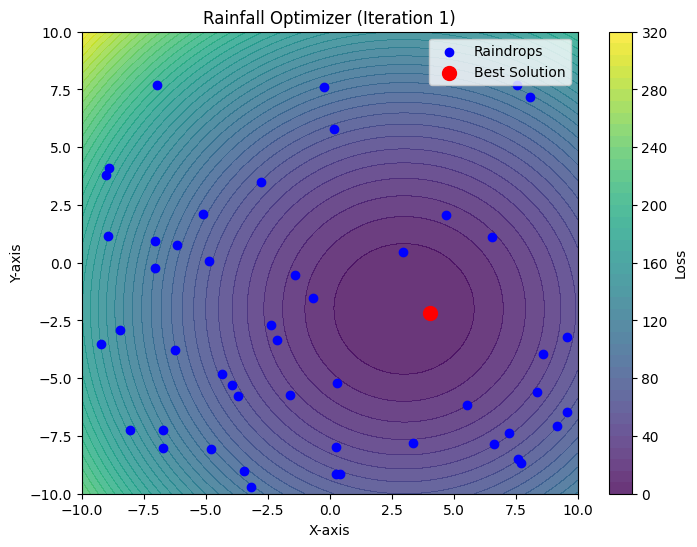

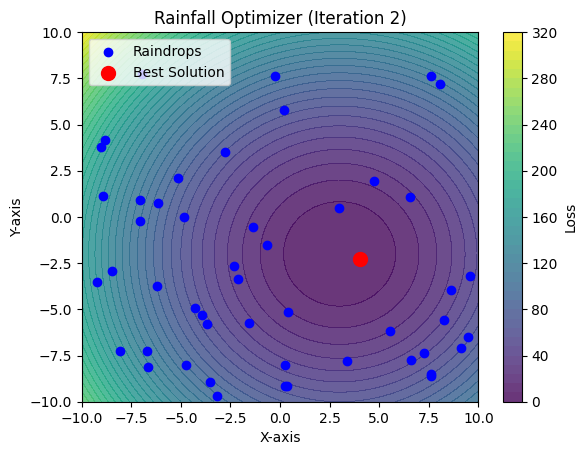

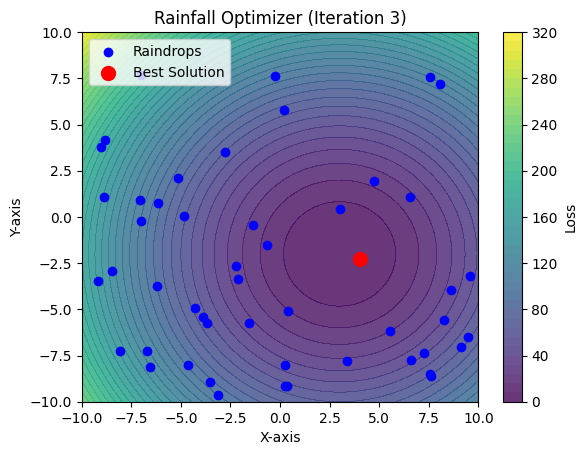

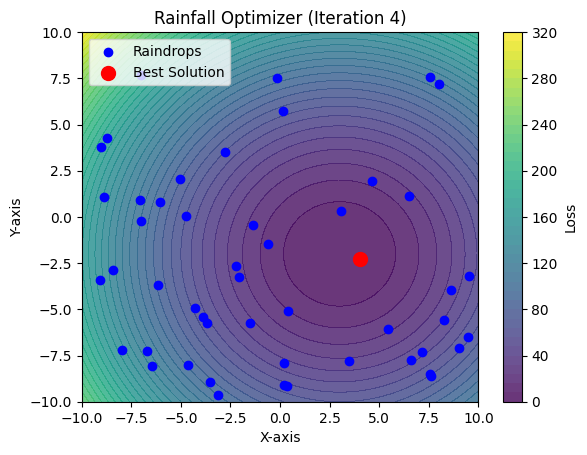

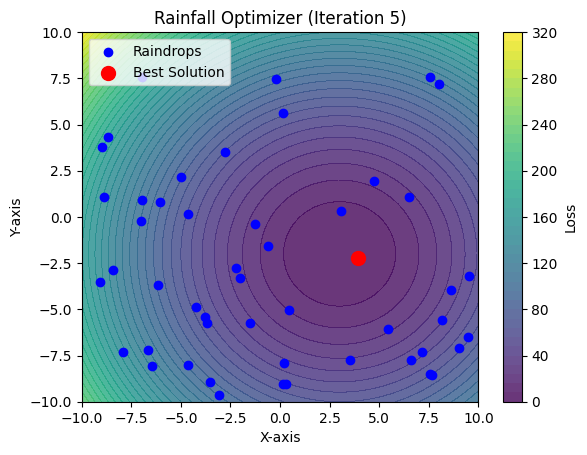

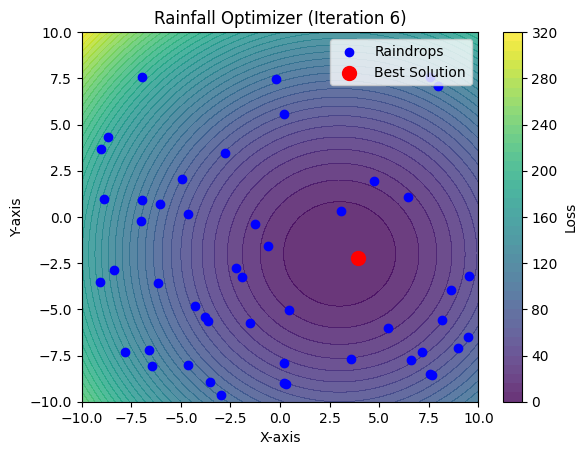

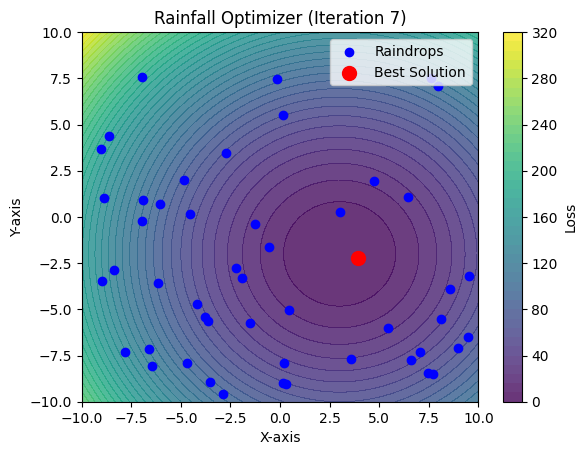

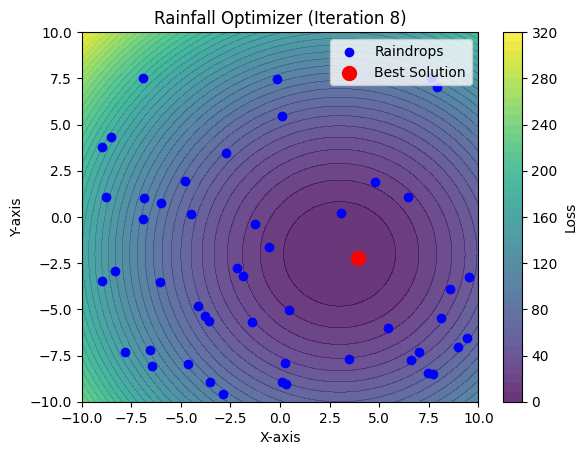

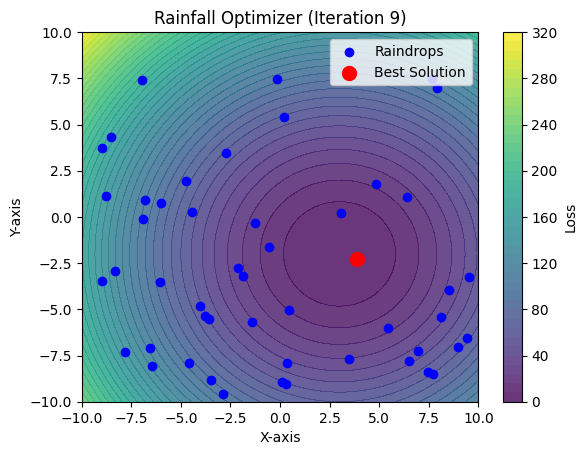

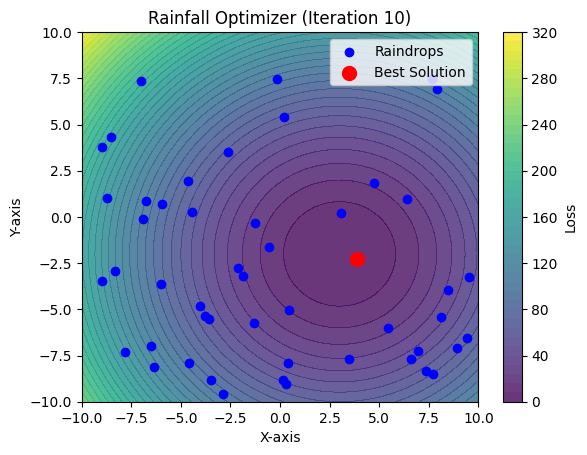

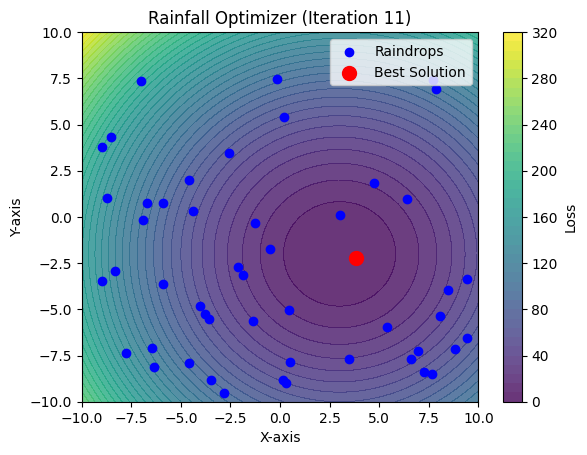

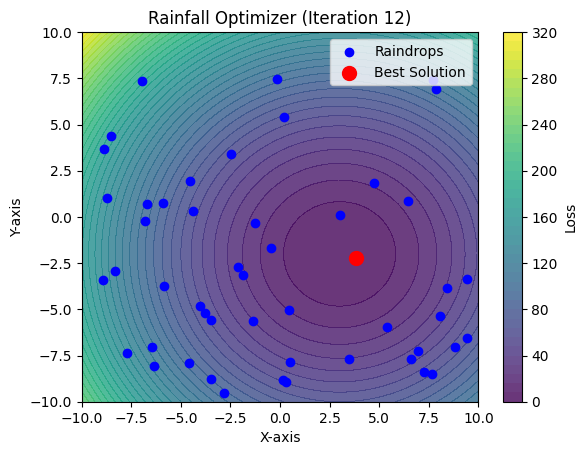

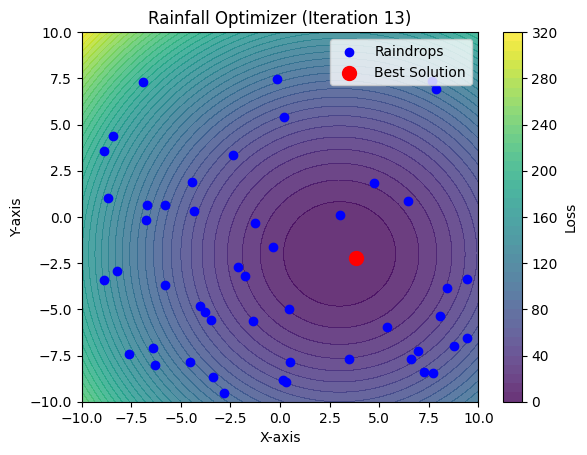

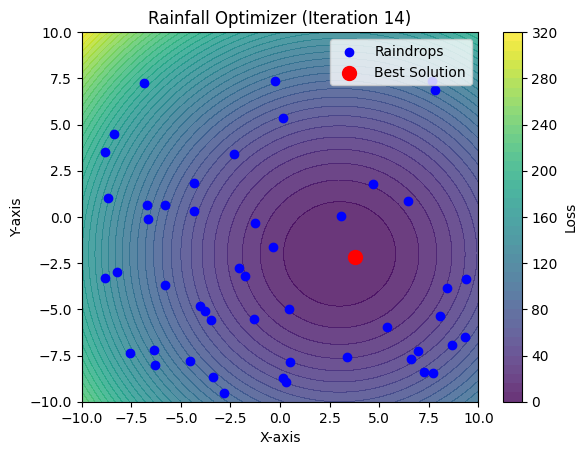

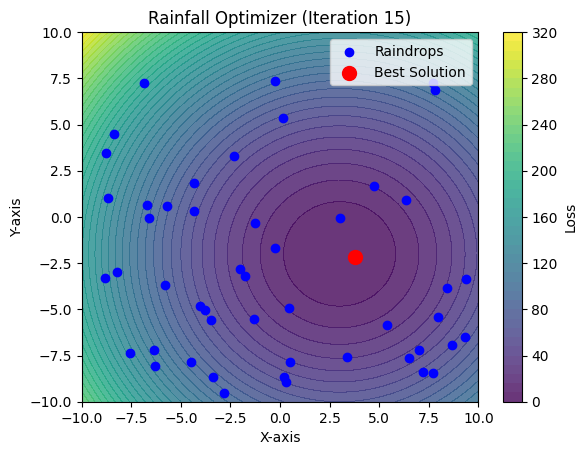

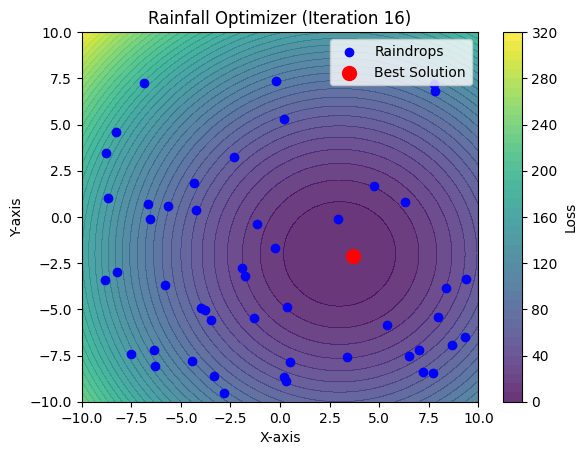

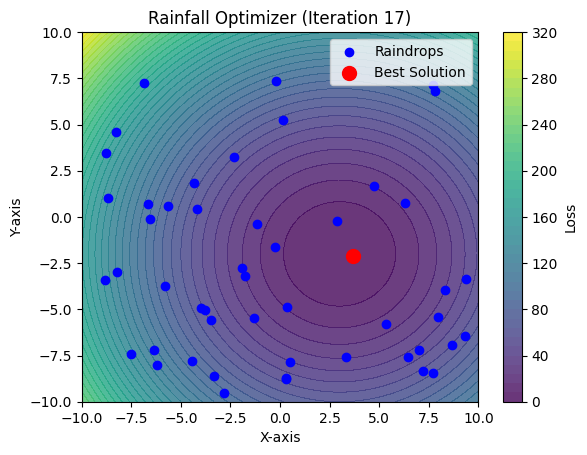

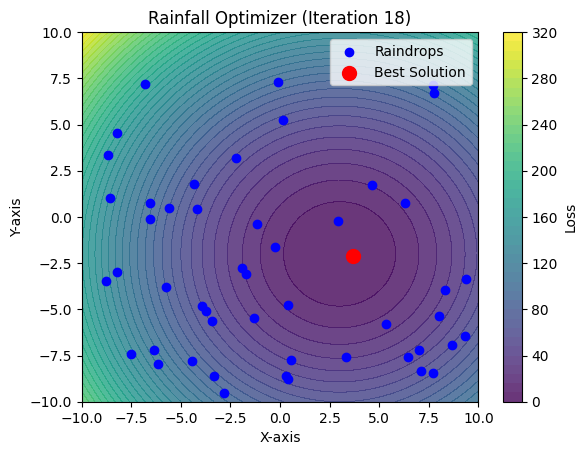

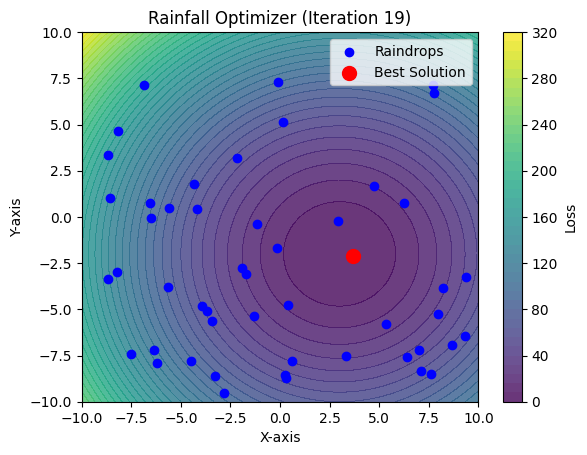

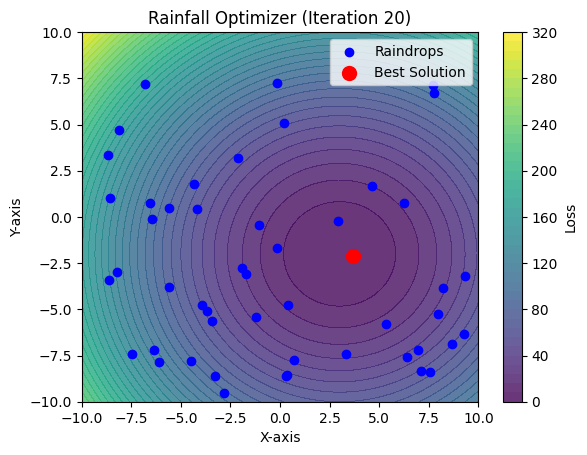

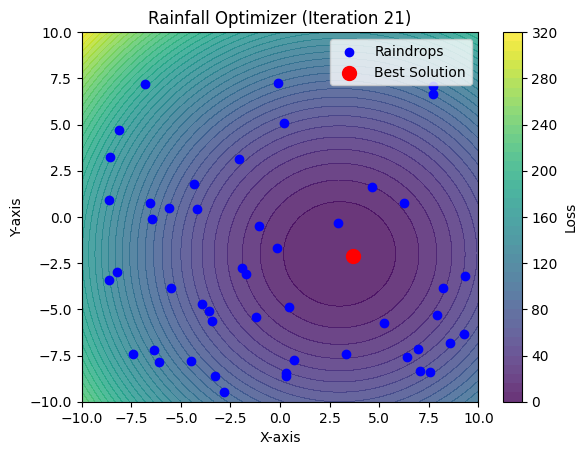

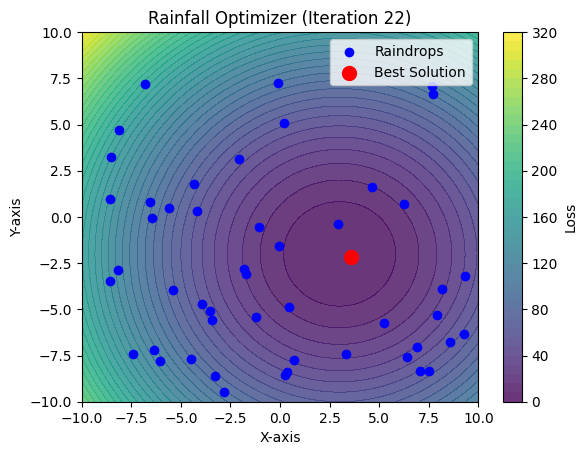

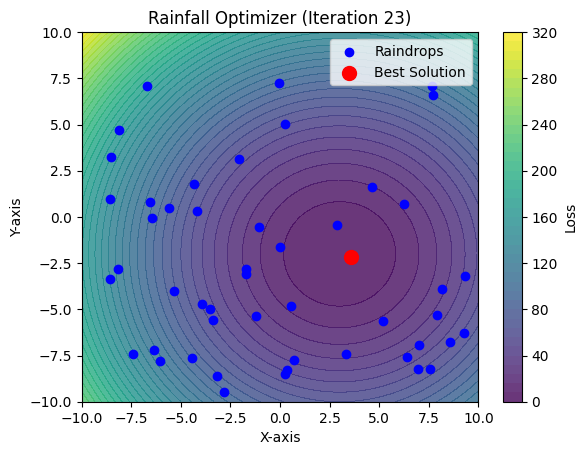

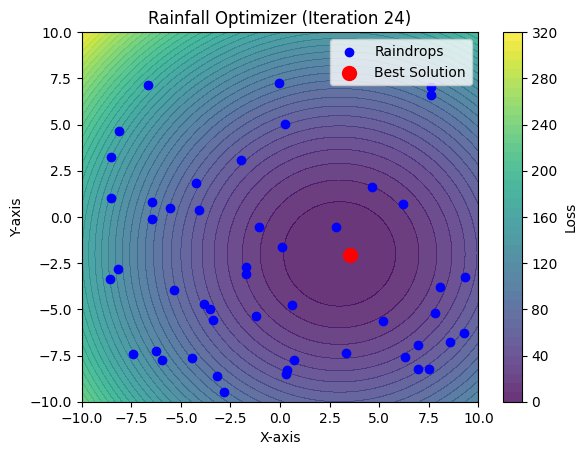

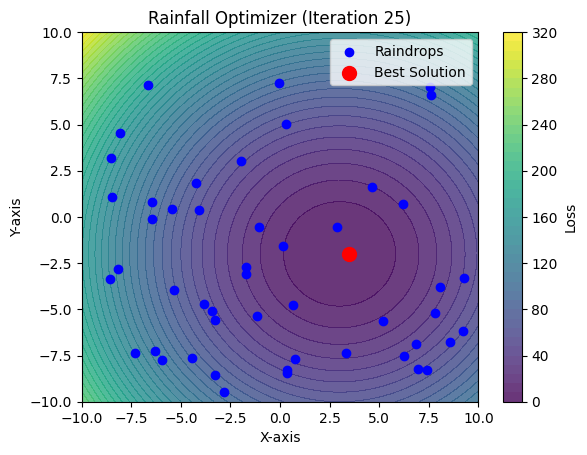

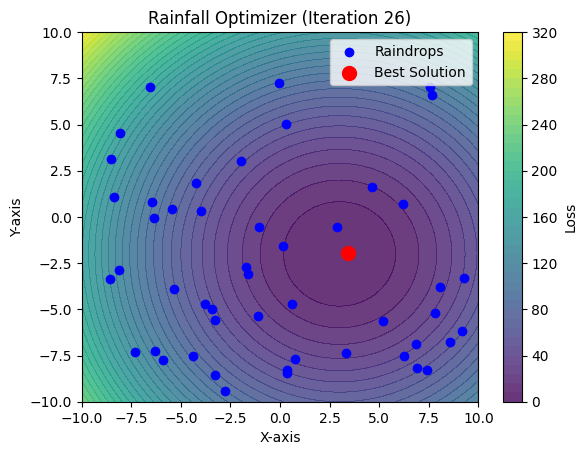

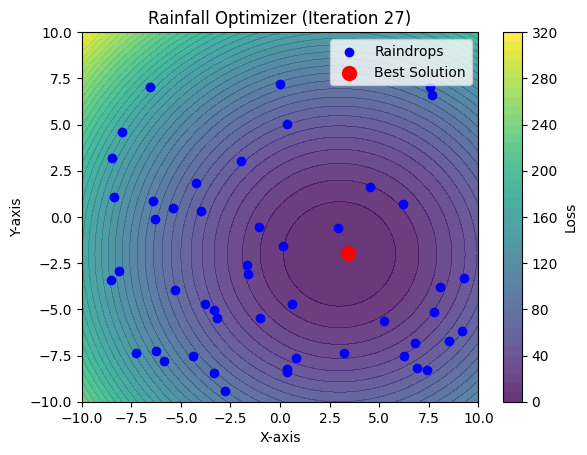

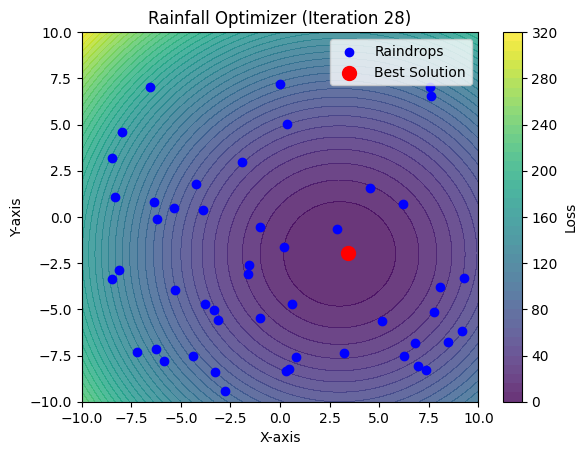

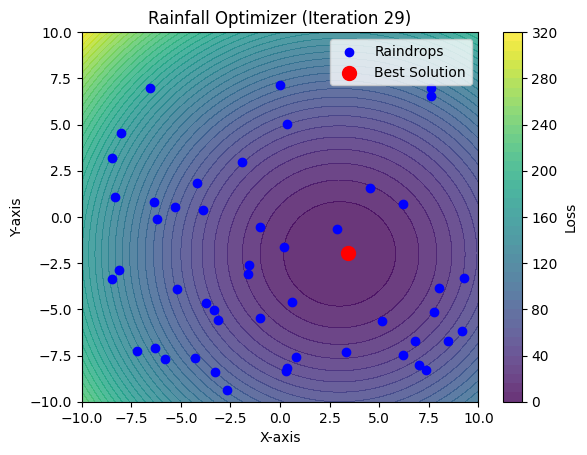

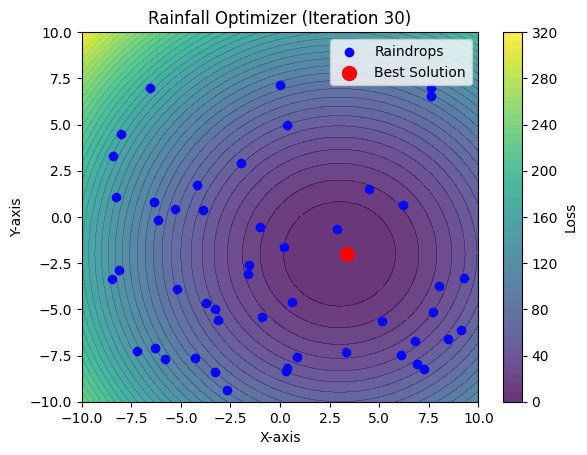

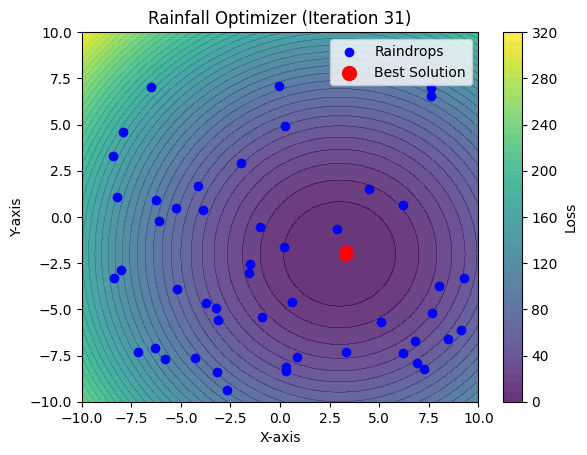

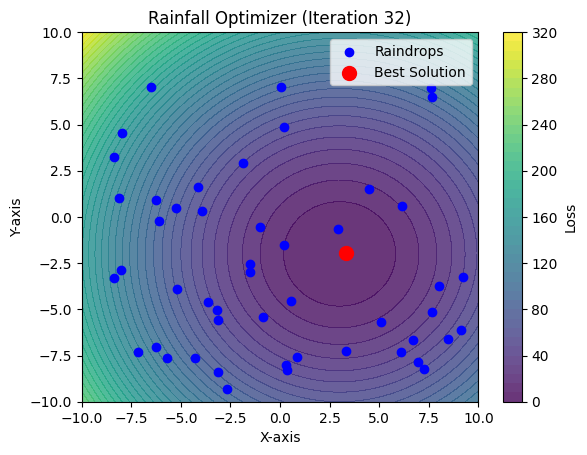

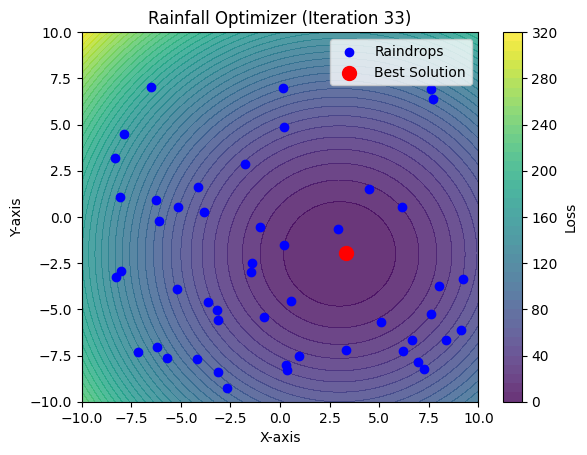

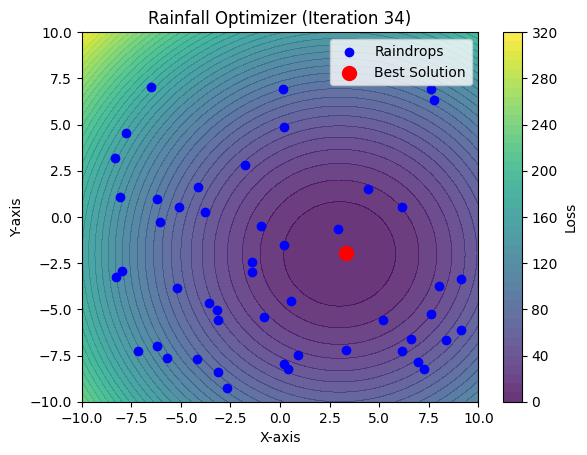

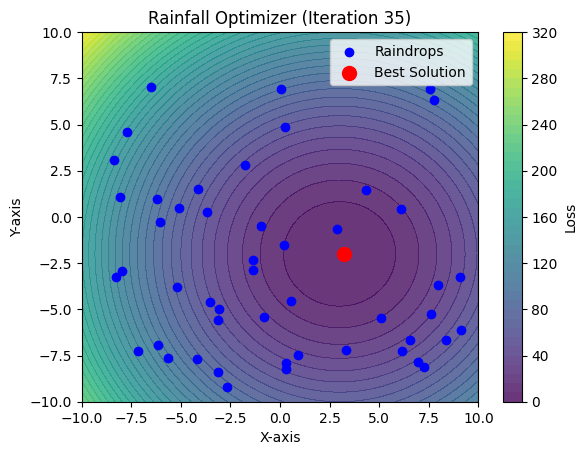

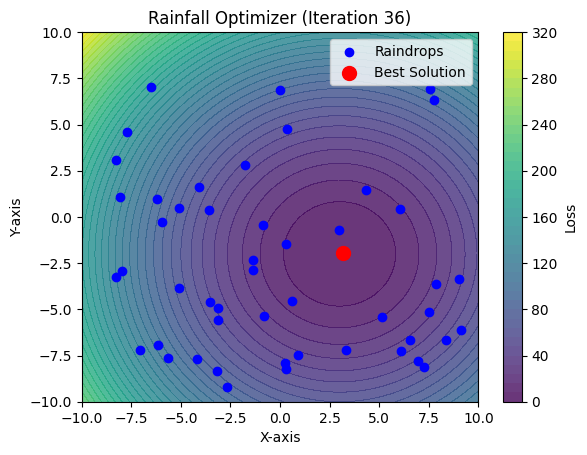

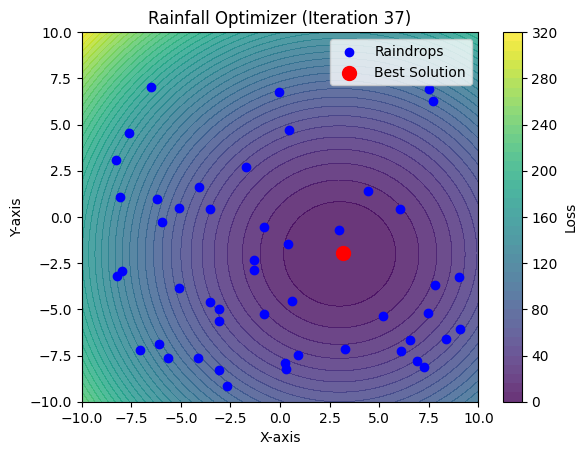

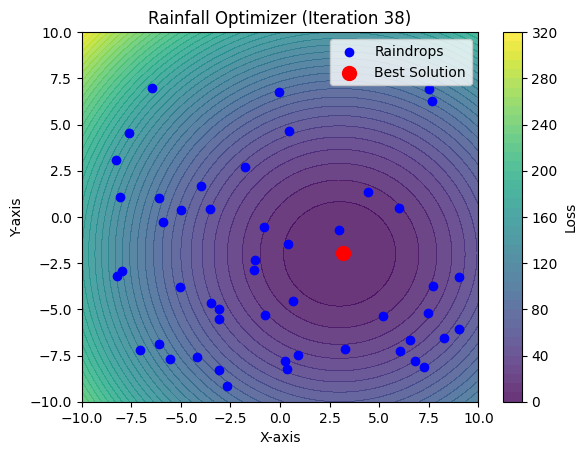

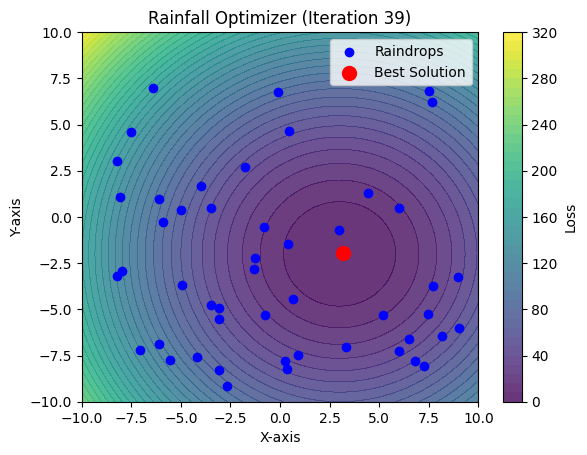

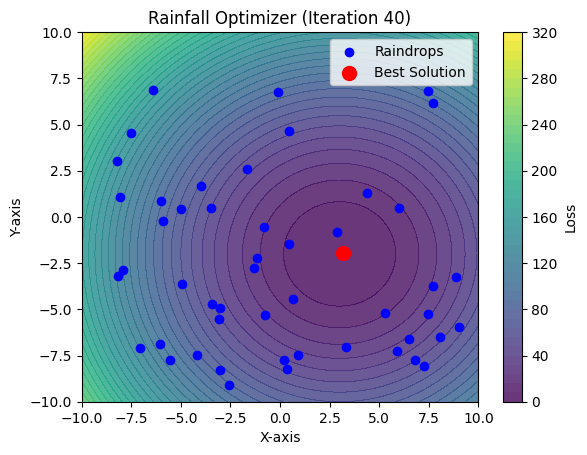

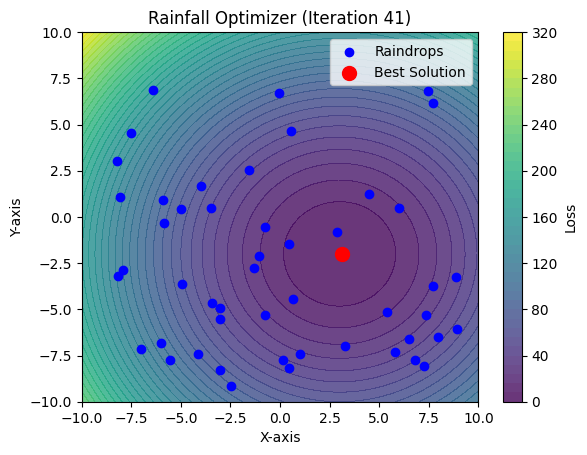

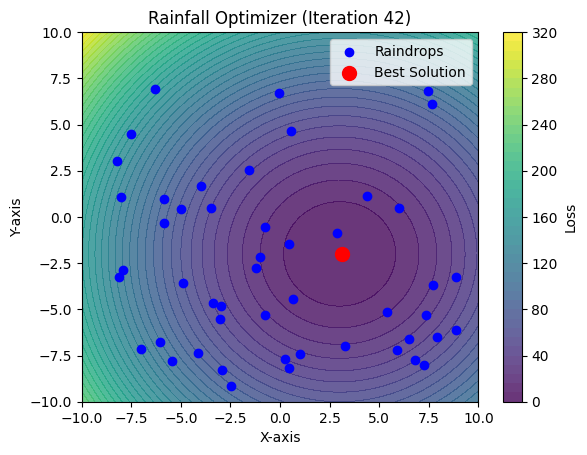

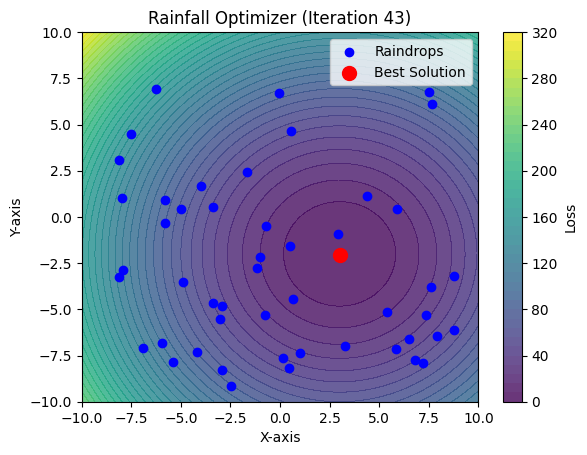

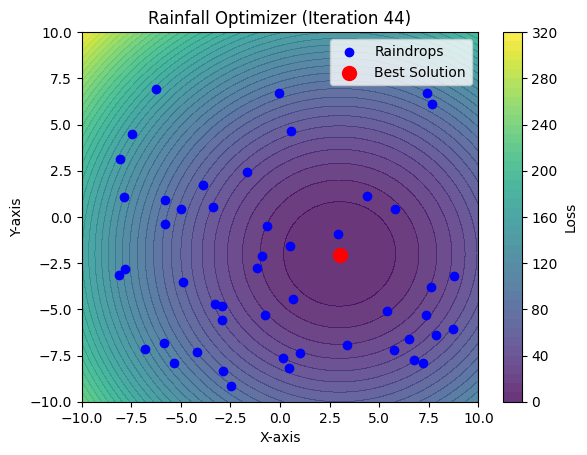

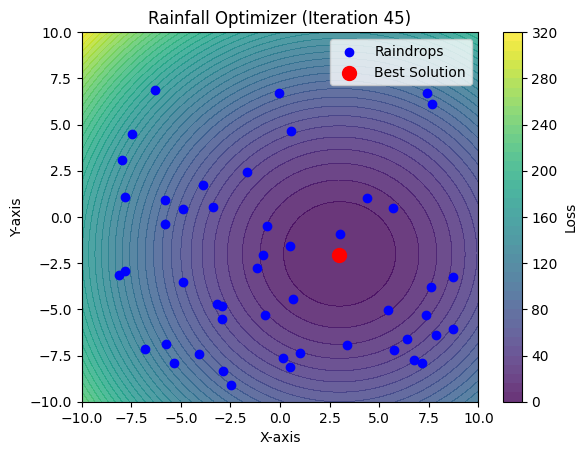

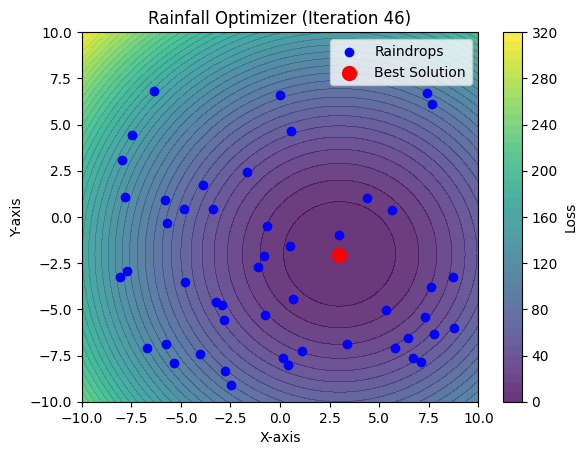

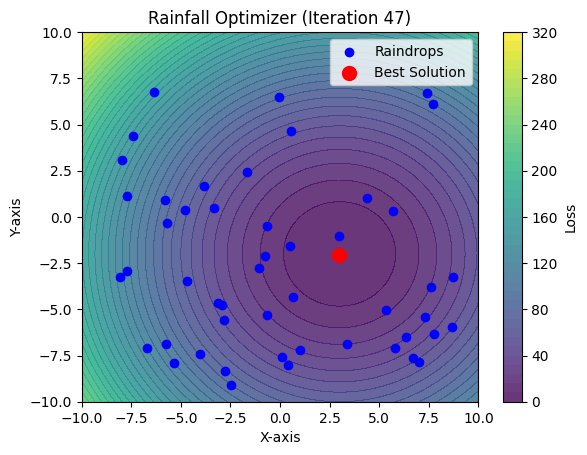

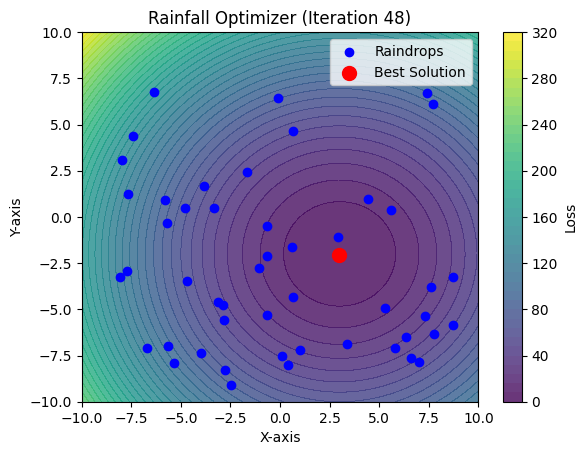

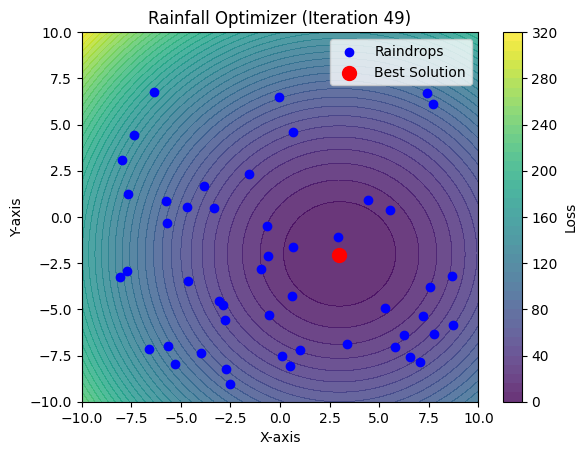

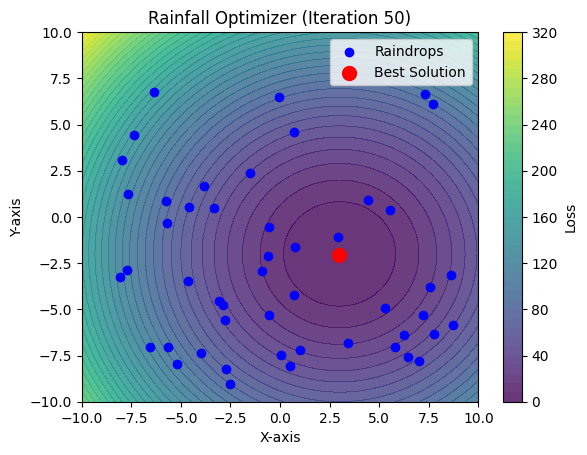

Best Solution: [ 2.99410648 -2.03412085]
Best Loss: 0.0011989658056891332


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def rainfall_optimizer_with_plot(loss_function, bounds, num_drops=50, max_iter=100, tol=1e-6):
    """
    Rainfall Optimizer with visualization.

    Parameters:
    - loss_function: The function to minimize.
    - bounds: A tuple (lower_bound, upper_bound) for the search space.
    - num_drops: Number of raindrops (candidate solutions).
    - max_iter: Maximum number of iterations.
    - tol: Convergence tolerance.

    Returns:
    - best_solution: Best solution found.
    - best_loss: Loss value at the best solution.
    """
    lower_bound, upper_bound = bounds
    dimension = len(lower_bound)

    # Initialize raindrops randomly within the bounds
    drops = np.random.uniform(lower_bound, upper_bound, (num_drops, dimension))
    losses = np.apply_along_axis(loss_function, 1, drops)

    best_solution = drops[np.argmin(losses)]
    best_loss = np.min(losses)

    # Setup the plot
    x = np.linspace(lower_bound[0], upper_bound[0], 100)
    y = np.linspace(lower_bound[1], upper_bound[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.array([loss_function([x_, y_]) for x_, y_ in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

    plt.figure(figsize=(8, 6))

    for iteration in range(max_iter):
        plt.clf()
        plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
        plt.colorbar(label='Loss')

        # Plot raindrops
        plt.scatter(drops[:, 0], drops[:, 1], c='blue', label='Raindrops')
        plt.scatter(best_solution[0], best_solution[1], c='red', label='Best Solution', s=100)
        plt.title(f"Rainfall Optimizer (Iteration {iteration + 1})")
        plt.xlabel('X-axis')
        plt.ylabel('Y-axis')
        plt.legend()
        plt.pause(0.3)  # Pause for animation

        # Update raindrops: randomly move them down the gradient
        new_drops = drops + np.random.uniform(-0.1, 0.1, drops.shape)  # Small random perturbation
        new_drops = np.clip(new_drops, lower_bound, upper_bound)  # Keep within bounds
        new_losses = np.apply_along_axis(loss_function, 1, new_drops)

        # Update if new position is better
        for i in range(num_drops):
            if new_losses[i] < losses[i]:
                drops[i] = new_drops[i]
                losses[i] = new_losses[i]

        # Update the best solution
        if np.min(losses) < best_loss:
            best_solution = drops[np.argmin(losses)]
            best_loss = np.min(losses)

        # Convergence check
        if best_loss < tol:
            break

    plt.show()
    return best_solution, best_loss

# Example loss function: f(x, y) = (x-3)^2 + (y+2)^2
def loss_function(point):
    x, y = point
    return (x - 3)**2 + (y + 2)**2

# Run the optimizer with visualization
bounds = [(-10, 10), (-10, 10)]  # Define bounds for x and y
best_solution, best_loss = rainfall_optimizer_with_plot(
    loss_function,
    bounds=[b for b in zip(*bounds)],
    num_drops=50,
    max_iter=50
)
print("Best Solution:", best_solution)
print("Best Loss:", best_loss)
